# Water Vapor Absorption Coefficient Verification

Compute and plot the H₂O line and continuum absorption cross-sections
$\sigma(\nu)$ [cm² molecule⁻¹] over 1–1000 GHz for a representative
mid-tropospheric atmospheric state:

| Parameter | Value |
|---|---|
| Pressure | 500 hPa |
| Temperature | 270 K |
| H₂O number density $n_{\rm H_2O}$ | 3.3 × 10²¹ cm⁻³ |

The **line contribution** comes from HITRAN line parameters via
`water_line_absorption`, which returns $\sigma_{\rm line}(\nu)$ in cm².

The **continuum contribution** from MT_CKD returns coefficients in cm⁵;
multiplying by the appropriate number densities gives $\sigma_{\rm cont}(\nu)$ in cm².

In [1]:
import sys
sys.path.insert(0, '..')

import jax
jax.config.update('jax_enable_x64', True)
jax.config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as sc

In [2]:
from atmo3 import water_line_emissions as wle
from atmo3 import water_continuum_emission as wce
from atmo3 import constants as con

## Atmospheric State

In [3]:
T      = 270.0    # K
P_hPa  = 500.0    # hPa  (total pressure)

# H₂O number density given directly
n_H2O_cm3 = 3.3e21   # cm⁻³

# Total number density from ideal gas law:  n_total = P / (k_B * T)
P_Pa      = P_hPa * 1e2                          # Pa
n_total   = P_Pa / (sc.k * T) * sc.centi**3      # cm⁻³
n_air     = n_total - n_H2O_cm3                  # dry-air number density [cm⁻³]

# Water vapour partial pressure for line computation
P_water_Pa   = n_H2O_cm3 * 1e6 * sc.k * T       # n [cm⁻³] → [m⁻³], then ×k_B×T
P_water_hPa  = P_water_Pa / 1e2

print(f"Total number density  : {n_total:.3e} cm⁻³")
print(f"H₂O number density    : {n_H2O_cm3:.3e} cm⁻³")
print(f"Dry-air number density: {n_air:.3e} cm⁻³")
print(f"H₂O partial pressure  : {P_water_hPa:.3e} hPa")

Total number density  : 1.341e+19 cm⁻³
H₂O number density    : 3.300e+21 cm⁻³
Dry-air number density: -3.287e+21 cm⁻³
H₂O partial pressure  : 1.230e+05 hPa


In [4]:
freq_GHz = jnp.logspace(jnp.log10(1.0), jnp.log10(1000.0), 2000)

## Line Absorption

`water_line_absorption` returns the spectral absorption cross-section
$\sigma_{\rm line}(\nu)$ [cm² molecule⁻¹] — the sum over all HITRAN lines of $S(T) \cdot F_{\rm VVH}(\nu)$.

In [5]:
sigma_line = wle.water_line_absorption(freq_GHz, T, P_hPa, P_water_hPa)
print(f"sigma_line  min={np.min(sigma_line):.3e}  max={np.max(sigma_line):.3e}  cm²/molecule")

sigma_line  min=2.617e-27  max=7.759e-21  cm²/molecule


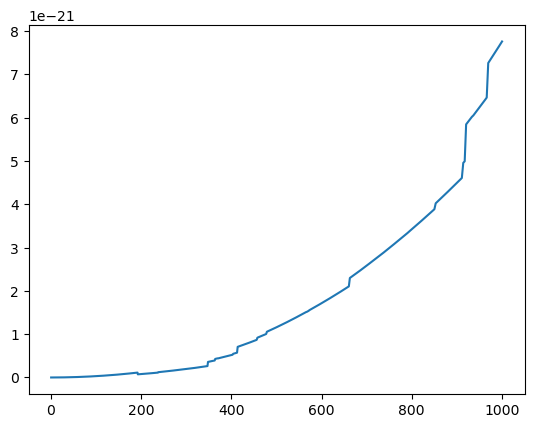

In [9]:
plt.plot(freq_GHz, sigma_line)

## Continuum Absorption

`water_continuum_absorption` returns $(k_{\rm self}, k_{\rm air})$ in cm⁵.
The cross-section per molecule is:

$$\sigma_{\rm cont}(\nu) = k_{\rm self}(\nu)\,n_{\rm H_2O} + k_{\rm air}(\nu)\,n_{\rm air}$$

In [6]:
k_self_cm5, k_air_cm5 = wce.water_continuum_absorption(freq_GHz, T)

sigma_self  = k_self_cm5 * n_H2O_cm3   # self-broadened continuum [cm²/molecule]
sigma_air   = k_air_cm5  * n_air        # foreign (air) continuum  [cm²/molecule]
sigma_cont  = sigma_self + sigma_air
sigma_total = sigma_line + sigma_cont

print(f"sigma_self  min={np.min(sigma_self):.3e}  max={np.max(sigma_self):.3e}  cm²/molecule")
print(f"sigma_air   min={np.min(sigma_air):.3e}   max={np.max(sigma_air):.3e}  cm²/molecule")
print(f"sigma_total min={np.min(sigma_total):.3e}  max={np.max(sigma_total):.3e}  cm²/molecule")

sigma_self  min=1.138e-24  max=9.405e-19  cm²/molecule
sigma_air   min=-4.050e-20   max=-3.365e-26  cm²/molecule
sigma_total min=1.107e-24  max=9.078e-19  cm²/molecule


## Plot

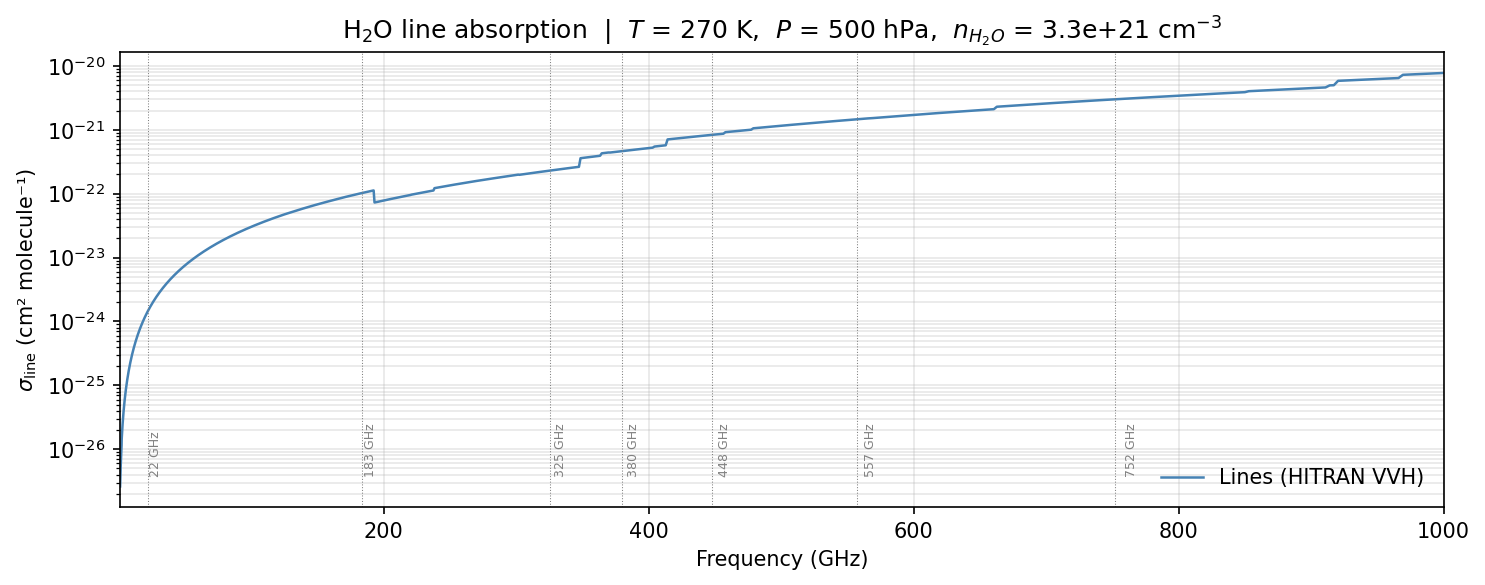

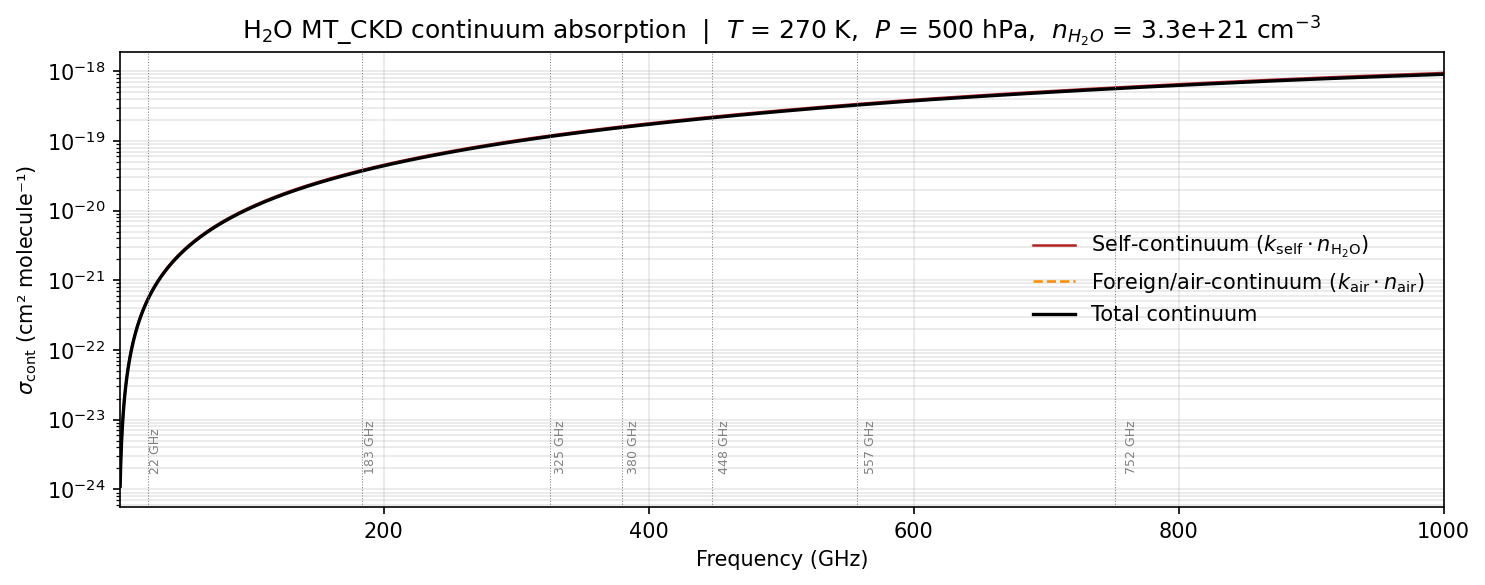

In [7]:
h2o_lines_GHz = [22.235, 183.310, 325.153, 380.197, 448.001, 556.936, 752.033]

def mark_lines(ax):
    ylo, yhi = ax.get_ylim()
    for nu0 in h2o_lines_GHz:
        ax.axvline(nu0, color='grey', lw=0.5, linestyle=':')
        ax.text(nu0 * 1.01, ylo * 3, f'{nu0:.0f} GHz', fontsize=6,
                rotation=90, va='bottom', ha='left', color='grey')

state_str = (fr'$T$ = {T:.0f} K,  $P$ = {P_hPa:.0f} hPa,  '
             fr'$n_{{H_2O}}$ = {n_H2O_cm3:.1e} cm$^{{-3}}$')

# ── Figure 1: Line absorption ──────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(10, 4), dpi=150)

ax1.semilogy(freq_GHz, np.array(sigma_line), lw=1.2, color='steelblue',
             label='Lines (HITRAN VVH)')
mark_lines(ax1)
ax1.set_xlabel('Frequency (GHz)')
ax1.set_ylabel(r'$\sigma_{\rm line}$ (cm² molecule⁻¹)')
ax1.set_title(fr'H$_2$O line absorption  |  {state_str}')
ax1.set_xlim(1, 1000)
ax1.legend(frameon=False)
ax1.grid(True, which='both', alpha=0.3)
fig1.tight_layout()
fig1.savefig('h2o_line_absorption.png', bbox_inches='tight')
plt.show()

# ── Figure 2: Continuum absorption ────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 4), dpi=150)

ax2.semilogy(freq_GHz, np.array(sigma_self),  lw=1.2, color='firebrick',
             label=r'Self-continuum ($k_{\rm self} \cdot n_{\rm H_2O}$)')
ax2.semilogy(freq_GHz, np.array(sigma_air),   lw=1.2, color='darkorange',
             linestyle='--',
             label=r'Foreign/air-continuum ($k_{\rm air} \cdot n_{\rm air}$)')
ax2.semilogy(freq_GHz, np.array(sigma_cont),  lw=1.6, color='k',
             label='Total continuum')
mark_lines(ax2)
ax2.set_xlabel('Frequency (GHz)')
ax2.set_ylabel(r'$\sigma_{\rm cont}$ (cm² molecule⁻¹)')
ax2.set_title(fr'H$_2$O MT_CKD continuum absorption  |  {state_str}')
ax2.set_xlim(1, 1000)
ax2.legend(frameon=False)
ax2.grid(True, which='both', alpha=0.3)
fig2.tight_layout()
fig2.savefig('h2o_continuum_absorption.png', bbox_inches='tight')
plt.show()

## Peak Values at Known H₂O Lines

In [8]:
freq_np = np.array(freq_GHz)

header = (f"{'Line (GHz)':>12}  {'σ_total':>13}  "
          f"{'σ_line':>13}  {'σ_self':>13}  {'σ_air':>13}")
print(header)
print("-" * len(header))
for nu0 in h2o_lines_GHz:
    idx = np.argmin(np.abs(freq_np - nu0))
    print(f"{nu0:>12.3f}  "
          f"{float(sigma_total[idx]):>13.3e}  "
          f"{float(sigma_line[idx]):>13.3e}  "
          f"{float(sigma_self[idx]):>13.3e}  "
          f"{float(sigma_air[idx]):>13.3e}")

  Line (GHz)        σ_total         σ_line         σ_self          σ_air
------------------------------------------------------------------------
      22.235      5.485e-22      1.497e-24      5.637e-22     -1.672e-23
     183.310      3.698e-20      1.021e-22      3.803e-20     -1.152e-21
     325.153      1.155e-19      2.298e-22      1.190e-19     -3.682e-21
     380.197      1.565e-19      4.642e-22      1.611e-19     -5.061e-21
     448.001      2.158e-19      8.376e-22      2.221e-19     -7.115e-21
     556.936      3.280e-19      1.464e-21      3.377e-19     -1.115e-20
     752.033      5.659e-19      3.016e-21      5.840e-19     -2.114e-20
